# **Intelligent Visual Analysis System**

### Image-Based Person Detection & Attribute Analysis

This notebook provides a simple interface for analyzing images containing one or more people.

The system automatically:

1. Detects people in the image.
2. Identifies visible facial regions.
3. Associates facial information with detected individuals.
4. Estimates selected visual attributes.
5. Displays the results directly on the image.
6. Provides a structured summary of the analysis.

> **Confidentiality Notice**
>
> This notebook is intended for authorized use only.
> The underlying models and implementation details are proprietary
> and should not be redistributed or reverse engineered.

## **How the System Works**

The system follows a two-stage analysis pipeline.

### **Stage 1 — Detection**

The first component analyzes the input image and identifies:

- Individual people
- Visible facial regions

### **Stage 2 — Attribute Analysis**

The detected regions are processed by a second analysis component to estimate the requested attributes.



In [7]:
!pip install -q \
    onnxruntime \
    onnxruntime-gpu \
    ultralytics \
    opencv-python-headless \
    numpy \
    pandas \
    matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 69.7 MB/s eta 0:00:00


In [9]:
!gdown https://drive.google.com/uc?id=1KnlU5iUC_foA_CybxCIaMRzefosIPaOM
!unzip /content/model_inference_package.zip

Downloading...
From (original): https://drive.google.com/uc?id=1crKvzHBnQnRho8Nuxut6-QyE7VVP7SOE
From (redirected): https://drive.google.com/uc?id=1crKvzHBnQnRho8Nuxut6-QyE7VVP7SOE&confirm=t&uuid=743fa5cb-151d-4294-87b8-c3e2c0c1320b
To: /content/model_inference_package.zip
100% 233M/233M [00:01<00:00, 134MB/s]
Archive:  /content/model_inference_package.zip
  inflating: detection_engine.pt     
  inflating: analysis_engine.onnx    
  inflating: analysis_engine.onnx.data  
  inflating: input.jpg               


In [10]:
from pathlib import Path

# ============================================================
# SYSTEM CONFIGURATION
# ============================================================

BASE_DIR = Path("/content")

DETECTION_MODEL = (
    BASE_DIR / "detection_engine.pt"
)

ANALYSIS_MODEL = (
    BASE_DIR / "analysis_engine.onnx"
)

OUTPUT_DIR = (
    BASE_DIR / "results"
)

OUTPUT_DIR.mkdir(
    exist_ok=True
)

DETECTION_CONFIDENCE = 0.25
DETECTION_IOU = 0.45
ANALYSIS_SIZE = 384

print("Configuration loaded.")

Configuration loaded.


In [11]:
import cv2
import numpy as np
import torch

from ultralytics import YOLO
import onnxruntime as ort

print("Loading system components...")


# ============================================================
# Detection Engine
# ============================================================

detector = YOLO(
    str(DETECTION_MODEL)
)


# ============================================================
# Analysis Engine
# ============================================================

device_preference = "cpu" # Set to "gpu" or "cpu" as needed for testing

available_providers = ort.get_available_providers()
providers = []

if device_preference == "cpu" and "CUDAExecutionProvider" in available_providers:
    providers.append("CPUExecutionProvider")

else:
    providers.append("CPUExecutionProvider")

analysis_session = ort.InferenceSession(
    str(ANALYSIS_MODEL),
    providers=providers,
)

print("System ready.")

Loading system components...
System ready.


In [12]:
print(
    "Available inference providers:"
)

print(
    analysis_session.get_providers()
)

Available inference providers:
['CPUExecutionProvider']


## 🖼️ **Use Your Own Image** (Optional)

The system is ready to run with the included **default test image** (`input.jpg`).

If you would like to analyze your **own image instead**, run the cell below and select an image from your computer when prompted.

> **Supported formats:** JPG, JPEG, PNG  
> **Recommendation:** Use a clear image with visible people for the best results.

**You only need to run the upload cell below if you want to replace the default `input.jpg`.**

After uploading your image, continue with the remaining analysis cells as usual.

In [21]:
from google.colab import files
from pathlib import Path
import cv2
import shutil

print(
    "Please select an image from your computer."
)

uploaded = files.upload()

uploaded_name = next(
    iter(uploaded.keys())
)

uploaded_path = Path(
    f"/content/{uploaded_name}"
)

image = cv2.imread(
    str(uploaded_path)
)

if image is None:
    raise ValueError(
        "The uploaded file could not be read as an image."
    )

IMAGE_PATH = str(
    uploaded_path
)

print("\n✓ Custom image loaded successfully.")
print(f"✓ Image: {uploaded_name}")
print(
    f"✓ Resolution: "
    f"{image.shape[1]} × {image.shape[0]} pixels"
)

print("\nReady for analysis.")

Please select an image from your computer.


Saving images.jpg to images.jpg

✓ Custom image loaded successfully.
✓ Image: images.jpg
✓ Resolution: 365 × 547 pixels

Ready for analysis.


## **Default Inference Image**

In [43]:
!wget -O input_2.jpg "https://images.unsplash.com/photo-1502307100811-6bdc0981a85b?fm=jpg&q=60&w=3000&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8cGVvcGxlJTIwYmFja3xlbnwwfHwwfHx8MA%3D%3D"

--2026-07-23 14:58:58--  https://images.unsplash.com/photo-1502307100811-6bdc0981a85b?fm=jpg&q=60&w=3000&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8cGVvcGxlJTIwYmFja3xlbnwwfHwwfHx8MA%3D%3D
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 902667 (882K) [image/jpeg]
Saving to: ‘input_2.jpg’

input_2.jpg         100%[===================>] 881.51K  --.-KB/s    in 0.04s   

2026-07-23 14:58:58 (24.6 MB/s) - ‘input_2.jpg’ saved [902667/902667]



In [44]:
from pathlib import Path
import cv2

DEFAULT_IMAGE_PATH = Path(
    "/content/input_2.jpg" # FACELESS  BACK-SHOWN Testing
)

# UNCOMMENT THE FOLLOWING SNIPPET IF YOU WANT TO RUN INFERENCE ON A DIFFERENT DEFAULT IMAGE DEPICTING A ADULT FEMALE
# DEFAULT_IMAGE_PATH = Path(
#     "/content/input.jpg"
# )

if not DEFAULT_IMAGE_PATH.exists():
    raise FileNotFoundError(
        "Default image 'input.jpg' was not found in /content."
    )

image = cv2.imread(
    str(DEFAULT_IMAGE_PATH)
)

if image is None:
    raise ValueError(
        "The default image could not be read."
    )

IMAGE_PATH = str(
    DEFAULT_IMAGE_PATH
)

print("✓ Default image loaded successfully.")
print(f"✓ Image: {DEFAULT_IMAGE_PATH.name}")
print(
    f"✓ Resolution: "
    f"{image.shape[1]} × {image.shape[0]} pixels"
)

print("\nReady for analysis.")

✓ Default image loaded successfully.
✓ Image: input_2.jpg
✓ Resolution: 3000 × 4608 pixels

Ready for analysis.


# 🔎 **STAGE 1** — PERSON & FACE DETECTION

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def detect_people_and_faces(
    image,
    confidence_threshold=0.25,
    iou_threshold=0.45
):
    """
    Detect people and faces in the input image.

    Returns:
        persons: List of person detections
        faces:   List of face detections
    """

    results = detector.predict(
        source=image,
        conf=confidence_threshold,
        iou=iou_threshold,
        verbose=False
    )

    result = results[0]

    persons = []
    faces = []

    for box in result.boxes:

        # Bounding box
        x1, y1, x2, y2 = (
            box.xyxy[0]
            .detach()
            .cpu()
            .numpy()
            .astype(int)
        )

        # Confidence
        confidence = float(
            box.conf[0]
            .detach()
            .cpu()
            .item()
        )

        # Class
        class_id = int(
            box.cls[0]
            .detach()
            .cpu()
            .item()
        )

        class_name = (
            result.names[class_id]
            .lower()
            .strip()
        )

        detection = {
            "box": (
                int(x1),
                int(y1),
                int(x2),
                int(y2)
            ),
            "confidence": confidence,
            "class_name": class_name
        }

        if class_name == "person":

            persons.append(
                detection
            )

        elif class_name == "face":

            faces.append(
                detection
            )

    persons.sort(
        key=lambda d: (
            d["box"][1],
            d["box"][0]
        )
    )

    faces.sort(
        key=lambda d: (
            d["box"][1],
            d["box"][0]
        )
    )


    return persons, faces

persons, faces = detect_people_and_faces(
    image=image,
    confidence_threshold=DETECTION_CONFIDENCE,
    iou_threshold=DETECTION_IOU
)


# ============================================================
# Detection Summary
# ============================================================

print("=" * 60)
print("DETECTION COMPLETE")
print("=" * 60)

print(
    f"👤 Persons detected : {len(persons)}"
)

print(
    f"🙂 Faces detected   : {len(faces)}"
)

DETECTION COMPLETE
👤 Persons detected : 1
🙂 Faces detected   : 0


# 🧠 **STAGE 2** — ATTRIBUTE ANALYSIS & VISUALIZATION

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def calculate_iou(box_a, box_b):
    """
    Calculate Intersection over Union between two boxes.
    """

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)

    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(
        0,
        inter_x2 - inter_x1
    )

    inter_h = max(
        0,
        inter_y2 - inter_y1
    )

    intersection = (
        inter_w *
        inter_h
    )

    area_a = (
        max(0, ax2 - ax1) *
        max(0, ay2 - ay1)
    )

    area_b = (
        max(0, bx2 - bx1) *
        max(0, by2 - by1)
    )

    union = (
        area_a +
        area_b -
        intersection
    )

    if union <= 0:
        return 0.0

    return (
        intersection /
        union
    )


def associate_faces_with_people(
    persons,
    faces
):
    """
    Associate each detected face with the
    most appropriate person bounding box.
    """

    associations = []

    for person_index, person in enumerate(
        persons
    ):

        person_box = person["box"]

        best_face = None
        best_iou = 0.0

        for face in faces:

            face_box = face["box"]

            iou = calculate_iou(
                person_box,
                face_box
            )

            if iou > best_iou:

                best_iou = iou
                best_face = face


        associations.append(
            {
                "person_index":
                    person_index,

                "person":
                    person,

                "face":
                    best_face,

                "association_score":
                    best_iou
            }
        )


    return associations

def preprocess_crop(
    crop,
    size=384
):

    if crop is None:
        raise ValueError(
            "Crop cannot be None."
        )

    crop = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    crop = cv2.resize(
        crop,
        (size, size),
        interpolation=cv2.INTER_LINEAR
    )

    crop = (
        crop.astype(
            np.float32
        )
        / 255.0
    )

    crop = np.transpose(
        crop,
        (2, 0, 1)
    )

    crop = np.expand_dims(
        crop,
        axis=0
    )

    return np.ascontiguousarray(
        crop,
        dtype=np.float32
    )


def create_empty_face_input(
    size=384
):

    return np.zeros(
        (
            1,
            3,
            size,
            size
        ),
        dtype=np.float32
    )


def analyze_person(
    face_crop,
    person_crop
):

    person_tensor = preprocess_crop(
        person_crop,
        ANALYSIS_SIZE
    )

    if face_crop is not None:

        face_tensor = preprocess_crop(
            face_crop,
            ANALYSIS_SIZE
        )

    else:

        face_tensor = create_empty_face_input(
            ANALYSIS_SIZE
        )


    outputs = analysis_session.run(
        None,
        {
            "faces_input":
                face_tensor,

            "body_input":
                person_tensor,
        }
    )


    estimated_age = float(
        np.asarray(
            outputs[0]
        ).flatten()[0]
    )

    gender_probability = float(
        np.asarray(
            outputs[1]
        ).flatten()[0]
    )

    gender_index = int(
        np.asarray(
            outputs[2]
        ).flatten()[0]
    )


    return {
        "estimated_age":
            estimated_age,

        "gender_probability":
            gender_probability,

        "category_index":
            gender_index,

        "face_available":
            face_crop is not None
    }


analysis_results = []


for person_index, person in enumerate(
    persons
):

    px1, py1, px2, py2 = (
        person["box"]
    )


    person_crop = image[
        max(0, py1):max(0, py2),
        max(0, px1):max(0, px2)
    ]


    best_face = None
    best_face_score = -1


    for face in faces:

        fx1, fy1, fx2, fy2 = (
            face["box"]
        )


        face_center_x = (
            fx1 + fx2
        ) / 2

        face_center_y = (
            fy1 + fy2
        ) / 2


        inside_person = (
            px1 <= face_center_x <= px2
            and
            py1 <= face_center_y <= py2
        )


        if not inside_person:

            continue


        face_area = (
            max(
                0,
                fx2 - fx1
            )
            *
            max(
                0,
                fy2 - fy1
            )
        )


        if face_area > best_face_score:

            best_face_score = (
                face_area
            )

            best_face = face


    if best_face is not None:

        fx1, fy1, fx2, fy2 = (
            best_face["box"]
        )


        face_crop = image[
            max(0, fy1):max(0, fy2),
            max(0, fx1):max(0, fx2)
        ]

    else:

        face_crop = None


    attributes = analyze_person(
        face_crop=face_crop,
        person_crop=person_crop
    )


    analysis_results.append(
        {
            "person_index":
                person_index,

            "person":
                person,

            "face":
                best_face,

            "analysis":
                attributes
        }
    )


print(
    f"✓ Analysis completed for "
    f"{len(analysis_results)} person(s)."
)


face_based_count = sum(
    1
    for result in analysis_results
    if result[
        "analysis"
    ][
        "face_available"
    ]
)


body_based_count = (
    len(analysis_results)
    -
    face_based_count
)


print(
    f"✓ Face-assisted analysis: "
    f"{face_based_count}"
)

print(
    f"✓ Body-only fallback analysis: "
    f"{body_based_count}"
)

✓ Analysis completed for 1 person(s).
✓ Face-assisted analysis: 0
✓ Body-only fallback analysis: 1


# 🎨 **CLEAN  VISUALIZATION**


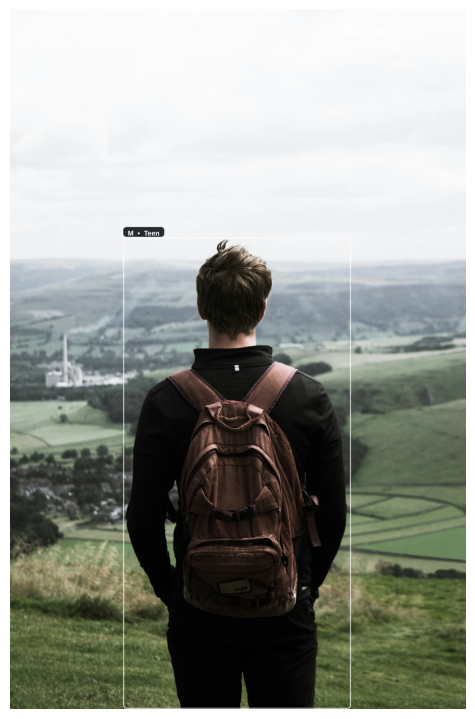

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

PERSON_LINE_WIDTH = 2
FACE_LINE_WIDTH = 2
BADGE_ALPHA = 225
BADGE_MARGIN = 6

GENDER_LABELS = {
    0: "M",
    1: "F",
}

def get_visualization_font(size, bold=False):
    if bold:
        font_paths = [
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf",
        ]
    else:
        font_paths = [
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
            "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        ]

    for font_path in font_paths:
        try:
            return ImageFont.truetype(font_path, size)
        except Exception:
            continue

    return ImageFont.load_default()


def get_age_bin(age):
    age = float(age)

    if age <= 11:
        return "Child"
    elif age <= 20:
        return "Teen"
    elif age <= 50:
        return "Adult"
    else:
        return "Elder"


def rectangles_overlap(box_a, box_b, margin=0):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    return not (
        ax2 + margin < bx1
        or ax1 - margin > bx2
        or ay2 + margin < by1
        or ay1 - margin > by2
    )


def is_inside_image(box, image_width, image_height):
    x1, y1, x2, y2 = box

    return (
        x1 >= 0
        and y1 >= 0
        and x2 <= image_width
        and y2 <= image_height
    )


def draw_rounded_box(draw, box, radius, outline, width):
    x1, y1, x2, y2 = box

    draw.rounded_rectangle(
        [x1, y1, x2, y2],
        radius=radius,
        outline=outline,
        width=width
    )


def draw_face_brackets(
    draw,
    box,
    color,
    width=2,
    corner_length=14,
    radius=5
):
    x1, y1, x2, y2 = box

    if x2 <= x1 or y2 <= y1:
        return

    box_width = x2 - x1
    box_height = y2 - y1

    corner_length = int(
        min(
            corner_length,
            box_width * 0.30,
            box_height * 0.30
        )
    )

    corner_length = max(corner_length, 5)

    draw.line(
        [(x1 + radius, y1), (x1 + corner_length, y1)],
        fill=color,
        width=width
    )

    draw.line(
        [(x1, y1 + radius), (x1, y1 + corner_length)],
        fill=color,
        width=width
    )

    draw.line(
        [(x2 - corner_length, y1), (x2 - radius, y1)],
        fill=color,
        width=width
    )

    draw.line(
        [(x2, y1 + radius), (x2, y1 + corner_length)],
        fill=color,
        width=width
    )

    draw.line(
        [(x1, y2 - corner_length), (x1, y2 - radius)],
        fill=color,
        width=width
    )

    draw.line(
        [(x1 + radius, y2), (x1 + corner_length, y2)],
        fill=color,
        width=width
    )

    draw.line(
        [(x2 - corner_length, y2), (x2 - radius, y2)],
        fill=color,
        width=width
    )

    draw.line(
        [(x2, y2 - corner_length), (x2, y2 - radius)],
        fill=color,
        width=width
    )


def find_best_badge_position(
    person_box,
    face_box,
    badge_width,
    badge_height,
    image_width,
    image_height,
    margin=6
):
    px1, py1, px2, py2 = person_box

    candidates = [
        (
            px1,
            py1 - badge_height - margin
        ),
        (
            px2 - badge_width,
            py1 - badge_height - margin
        ),
        (
            px1,
            py2 + margin
        ),
        (
            px2 - badge_width,
            py2 + margin
        ),
        (
            px1 + margin,
            py1 + margin
        ),
        (
            px2 - badge_width - margin,
            py1 + margin
        ),
    ]

    for x, y in candidates:
        candidate_box = (
            x,
            y,
            x + badge_width,
            y + badge_height
        )

        if not is_inside_image(
            candidate_box,
            image_width,
            image_height
        ):
            continue

        if face_box is not None:
            if rectangles_overlap(
                candidate_box,
                face_box,
                margin=4
            ):
                continue

        return x, y

    for x, y in candidates:
        candidate_box = (
            x,
            y,
            x + badge_width,
            y + badge_height
        )

        if is_inside_image(
            candidate_box,
            image_width,
            image_height
        ):
            return x, y

    return (
        max(
            0,
            min(
                px1,
                image_width - badge_width
            )
        ),
        max(
            0,
            min(
                py1,
                image_height - badge_height
            )
        )
    )


rgb_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

canvas = Image.fromarray(
    rgb_image
)

draw = ImageDraw.Draw(
    canvas,
    "RGBA"
)

image_width, image_height = canvas.size

scale = max(
    1.0,
    min(
        image_width,
        image_height
    ) / 900.0
)

badge_font = get_visualization_font(
    max(
        11,
        int(
            14 * scale
        )
    ),
    bold=True
)

person_line_width = max(
    1,
    int(
        PERSON_LINE_WIDTH * scale
    )
)

face_line_width = max(
    1,
    int(
        FACE_LINE_WIDTH * scale
    )
)

PERSON_COLOR = (
    255,
    255,
    255,
    210
)

FACE_COLOR = (
    90,
    200,
    255,
    255
)

BADGE_BACKGROUND = (
    10,
    14,
    22,
    BADGE_ALPHA
)

BADGE_BORDER = (
    255,
    255,
    255,
    65
)

TEXT_COLOR = (
    255,
    255,
    255,
    255
)

for result in analysis_results:

    person = result["person"]
    face = result["face"]
    analysis = result["analysis"]

    px1, py1, px2, py2 = person["box"]

    person_box = (
        px1,
        py1,
        px2,
        py2
    )

    draw_rounded_box(
        draw=draw,
        box=person_box,
        radius=int(
            7 * scale
        ),
        outline=PERSON_COLOR,
        width=person_line_width
    )

    if face is not None:

        fx1, fy1, fx2, fy2 = face["box"]

        face_box = (
            fx1,
            fy1,
            fx2,
            fy2
        )

        draw_face_brackets(
            draw=draw,
            box=face_box,
            color=FACE_COLOR,
            width=face_line_width,
            corner_length=int(
                14 * scale
            ),
            radius=int(
                4 * scale
            )
        )

    else:

        face_box = None

    if analysis is not None:

        age = float(
            analysis[
                "estimated_age"
            ]
        )

        gender_index = int(
            analysis[
                "category_index"
            ]
        )

        gender_label = GENDER_LABELS.get(
            gender_index,
            f"Class {gender_index}"
        )

        age_label = get_age_bin(
            age
        )

        badge_text = (
            f"{gender_label}"
            f"  •  "
            f"{age_label}"
        )

    else:

        badge_text = (
            "Analysis unavailable"
        )

    text_bbox = draw.textbbox(
        (0, 0),
        badge_text,
        font=badge_font
    )

    text_width = (
        text_bbox[2]
        -
        text_bbox[0]
    )

    text_height = (
        text_bbox[3]
        -
        text_bbox[1]
    )

    padding_x = max(
        7,
        int(
            9 * scale
        )
    )

    padding_y = max(
        4,
        int(
            5 * scale
        )
    )

    badge_width = (
        text_width
        +
        padding_x * 2
    )

    badge_height = (
        text_height
        +
        padding_y * 2
    )

    badge_x, badge_y = find_best_badge_position(
        person_box=person_box,
        face_box=face_box,
        badge_width=badge_width,
        badge_height=badge_height,
        image_width=image_width,
        image_height=image_height,
        margin=BADGE_MARGIN
    )

    draw.rounded_rectangle(
        [
            badge_x,
            badge_y,
            badge_x + badge_width,
            badge_y + badge_height
        ],
        radius=max(
            5,
            int(
                6 * scale
            )
        ),
        fill=BADGE_BACKGROUND,
        outline=BADGE_BORDER,
        width=1
    )

    draw.text(
        (
            badge_x + padding_x,
            badge_y + padding_y - 1
        ),
        badge_text,
        font=badge_font,
        fill=TEXT_COLOR
    )

plt.figure(
    figsize=(
        11,
        7
    )
)

plt.imshow(
    canvas
)

plt.axis(
    "off"
)

plt.tight_layout(
    pad=0
)

plt.show()

Do not worry, the following is for our debugging:

In [50]:
print(
    "ONNX INPUTS"
)

for inp in analysis_session.get_inputs():

    print(
        "Name:",
        inp.name
    )

    print(
        "Shape:",
        inp.shape
    )

    print(
        "Type:",
        inp.type
    )

    print()

ONNX INPUTS
Name: faces_input
Shape: ['batch', 3, 384, 384]
Type: tensor(float)

Name: body_input
Shape: ['batch', 3, 384, 384]
Type: tensor(float)

